<table>
    <tr>
        <td><img src="https://s3.amazonaws.com/media-p.slid.es/uploads/1485763/images/9060062/Header.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:#6A0DAD;text-align:center"> <FONT COLOR="#6A0DAD"> Árboles de Desición</FONT> </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Sesión 4</p></tp>
            <tp><p style="font-size:115%;text-align:center">4 de Abril 2026</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Daniel Rambaut </p></tp>
        </td>
    </tr>
</table>

En este notebook profundizaremos en uno de los modelos más interpretables del machine learning:

- **Árboles de Decisión** (modelo de machine learning supervisado)
- **Poda (Pruning)**: estrategias para evitar el sobreajuste
- **CCP (Cost Complexity Pruning)**: el método estándar de scikit-learn para la poda óptima

---
# <FONT SIZE=5 COLOR="green"> 0. Repaso de la sesión anterior </FONT>

En la sesión pasada exploramos herramientas para evaluar y mejorar modelos de clasificación. Los conceptos clave fueron:

<FONT COLOR="green" SIZE=3>1. Regresión Logística:</FONT>  
Un modelo que, a diferencia de predecir un número, predice la *probabilidad* de que algo ocurra. Por ejemplo: ¿qué tan probable es que este paciente tenga enfermedad cardíaca? Si esa probabilidad supera cierto umbral (normalmente 50%), el modelo dice "sí tiene enfermedad". Si no lo supera, dice "no tiene".

<FONT COLOR="green" SIZE=3>2. Curva ROC:</FONT>
<br>
Una gráfica que nos dice qué tan bien separa el modelo los casos positivos de los negativos. Cuanto más se acerca la curva a la esquina superior izquierda del gráfico, mejor es el modelo. Un modelo que adivina al azar produce una línea diagonal. El número que resume esta curva se llama **AUC** (Área Bajo la Curva): un valor cercano a 1.0 es excelente, y 0.5 es equivalente a lanzar una moneda.

<FONT COLOR="green" SIZE=3>3. Umbral de Decisión (Threshold):</FONT>
<br>El punto de corte que usamos para decidir cuándo el modelo dice "sí" o "no". El valor por defecto es 50%, pero podemos ajustarlo. Si bajamos el umbral (por ejemplo a 30%), el modelo será más "generoso" para decir "sí" — detectará más casos positivos pero también cometerá más errores. Si lo subimos, será más estricto. La decisión de dónde poner este umbral depende del problema: en medicina, preferimos detectar más casos aunque nos equivoquemos un poco, antes que dejar pasar enfermedades.

---

# <FONT SIZE=5 COLOR="blue"> 1. Introducción al modelo </FONT>


## <FONT SIZE=4 COLOR="blue"> 1.1 Librerías de trabajo </FONT>

In [ ]:
# Manipulación de data.frames
import pandas as pd
import numpy  as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler

# Árbol de Decisión
from sklearn.tree               import DecisionTreeClassifier, export_graphviz, plot_tree

# Métricas de evaluación
from sklearn.metrics            import (confusion_matrix, ConfusionMatrixDisplay,
                                        classification_report, accuracy_score,
                                        precision_score, recall_score, f1_score,
                                        roc_auc_score, roc_curve)
from imblearn.metrics           import specificity_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV, cross_val_score

# Para visualizar árboles
from graphviz import Source

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

## <FONT SIZE=4 COLOR="blue"> 1.2 Contexto del problema </FONT>

En este notebook usaremos el conjunto de datos **Heart Disease** del repositorio de la UCI (Cleveland Heart Disease Dataset).  
El objetivo es predecir si un paciente tiene o no enfermedad cardíaca a partir de variables clínicas.

- ***age***: Edad del paciente (años)
- ***sex***: Sexo (1 = masculino, 0 = femenino)
- ***cp***: Tipo de dolor en el pecho (0–3)
- ***trestbps***: Presión arterial en reposo (mm Hg)
- ***chol***: Colesterol sérico (mg/dl)
- ***fbs***: Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no)
- ***restecg***: Resultados del ECG en reposo (0–2)
- ***thalach***: Frecuencia cardíaca máxima alcanzada
- ***exang***: Angina inducida por ejercicio (1 = sí, 0 = no)
- ***oldpeak***: Depresión del ST inducida por ejercicio respecto al reposo
- ***slope***: Pendiente del segmento ST en el ejercicio pico (0–2)
- ***ca***: Número de vasos principales coloreados por fluoroscopía (0–3)
- ***thal***: Tipo de talasemia (0 = normal, 1 = defecto fijo, 2 = defecto reversible)
- ***target***: Variable que queremos predecir:
   - $1$ : Tiene enfermedad cardíaca
   - $0$ : No tiene enfermedad cardíaca

## <FONT SIZE=4 COLOR="blue"> 1.3 Importar los datos </FONT>

In [ ]:
# Cargar los datos
heart = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/cursos/refs/heads/master/Diplomado_Ciencia_Datos/heart.csv")
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Forma del dataset y tipos de datos
print(f"Dimensiones: {heart.shape}")
print()
print(heart.dtypes)

Dimensiones: (303, 14)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
# Estadísticos descriptivos
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(heart.isnull().sum())

Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


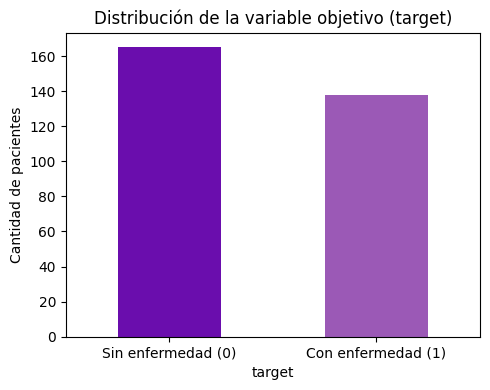

In [ ]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5,4))
heart["target"].value_counts().plot(kind="bar", color=["#6A0DAD","#9B59B6"], ax=ax)
ax.set_title("Distribución de la variable objetivo (target)")
ax.set_xticklabels(["Sin enfermedad (0)", "Con enfermedad (1)"], rotation=0)
ax.set_ylabel("Cantidad de pacientes")
plt.tight_layout()
plt.show()

# <FONT SIZE=5 COLOR="purple"> 2. Árboles de Decisión </FONT>

- El enfoque de clasificación y regresión vía árboles (CART, classification and regression tree) fue desarrollado por Breiman et al. (1984).

- Un árbol de decisión es una estructura que incluye un ***nodo raíz, nodos principales, ramas y nodos hoja***. Cada nodo interno denota una prueba sobre un atributo, cada rama denota el resultado de una prueba y cada nodo hoja contiene una etiqueta de clase. El nodo superior del árbol también es llamado: **nodo raíz**.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree1.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Los términos que intervienen en el algoritmo de árbol de decisión son los siguientes

- ***Nodo raíz:***: Es el nodo inicial del árbol.

- ***División:*** Es un proceso de división de un nodo en dos o más subnodos.

- ***Nodo de decisión***: Cuando un subnodo se divide en otros subnodos, se denomina nodo de decisión.

- ***Nodo hoja/terminal***: Son los nodos que no se dividen más.

- ***Rama/Subárbol***:  Una subsección de un árbol completo que inicia con un nodo principal.

- ***Profundidad (depth):*** Es el número de niveles de decisión en el árbol.

- ***Poda (prunning)***: Es el proceso de eliminar nodos de decisión con el fin de hacer el árbol más pequeño

Esta técnica de machine learning toma una serie de decisiones binarias en forma de árbol. Los nodos intermedios (las ramas) representan soluciones y los nodos finales (las hojas) nos dan la predicción que buscamos.

Para seleccionar las condiciones que conforman el árbol se usan dos elementos que se describirán más adelante.

  - Indice de Gini
  - Ganancia de Información (Entropía)


Lo primero que debemos indicar es que el algoritmo se basa en una serie de decisiones binarias, que gráficamente, no es más que una división de una región del plano donde están los datos.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree2.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Esta división se hace con el fin de separar un conjunto de puntos en las clases correspondientes. Consideremos el siguiente conjunto de puntos:

$$\{(x_i,y_i) \mid i = 1,2,3, \dots 29\}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree13.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Buscamos hacer divisiones rectangulares con el fin de separar los puntos. Para esto debemos iniciar con una condición, pero ¿cómo se hace esto?

Para responder está pregunta debemos hacer una grilla o cuadrícula tomando como referencia puntos entre cada $(x_i,x_{i+1}$) y $(y_i,y_{i+1})$.Por lo general se toma el punto medio

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree3.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora, debemos determinar cuál condición $x \leq x_i$ o $y \leq y_j$ es más apropiada para iniciar. Esta condición nos dará el nodo raíz que es el inicio del algoritmo.

Es en este punto donde debemos tener un criterio de decisión. Para ello hay dos alternativas: usar el índice de Gini o la Entropía, con el fin de determinar la mejor condición.

- El índice de Gini dice que, si seleccionamos al azar dos elementos de una población, deben ser de la misma clase y la probabilidad de que esto ocurra es 1 si la población es pura. En otras palabras, este índice permite determinar si un conjunto de puntos es homogéneo o no.

- Este índice funciona con la variable objetivo categórica "Éxito" o "Fracaso". Sólo realiza divisiones binarias.

*Cuanto menor sea el valor de Gini, mayor será la homogeneidad.*

- El **índice de Gini** está dado en general como:

$$Gini = 1-\sum \limits_{k=1}^{n}p_k^2$$

donde $p_k$ es la probabilidad de seleccionar un objeto de la clase $k$ en un determinado nodo.

Veamos un ejemplo de dos condiciones:

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree14.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora bien, para determinar si elegimos una condición o no, usaremos el concepto de *impureza*, que se define de la siguiente manera

$$\text{Impureza de un nodo} = (Gini) \times (\text{Ponderacion de los nodos})$$

Supongamos que en nuestro ejemplo ( de los puntos dados arriba) queremos saber cuál condición es mejor, es decir, tiene un nivel de impureza menor.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree5.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Es importante resaltar que el algoritmo compara todas las impurezas y escoje la menor. En ese sentido, la función de costo para los árboles de clasificación es:

$$\text{función de costo} = 1-\sum \limits_{k=1}^{n}p_k^2$$

Partiendo de esta condición, comenzamos la división en el árbol buscando minimizar esta función.

En las siguientes imágenes se observan las divisiones del árbol para diferentes valores

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree4.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree6.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree7.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

**Observación:** El método de árboles de decisión busca minimizar el índice de Gini y esto se puede lograr dividiendo el árbol de manera exhaustiva. Es decir, practicamente que cada punto este en una región. Pero esto es malo, ya que estamos *sobreajustando* el modelo. En otras palabras, el modelo clasifica perfectamente los datos del conjunto de entrenamiento pero no clasificará bien en los datos de prueba.

## <FONT SIZE=4 COLOR="purple"> 2.1 Modelo base del árbol de decisión </FONT>

In [ ]:
# 1. Definir variables
X = heart.drop("target", axis=1)
y = heart["target"]

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify    = y,
    random_state = 123,
    test_size   = 0.3 # ¿De qué tamaño quedó el test y el train?
)

# 3. Árbol sin restricciones (crecimiento máximo)
modelo_tree = DecisionTreeClassifier(random_state=123)
modelo_tree.fit(X_train, y_train) # Entrenamiento del modelo

# 4. Predicciones
y_pred = modelo_tree.predict(X_test)

# 5. Métricas
print("Profundidad del árbol:", modelo_tree.get_depth())
print("Número de hojas:      ", modelo_tree.get_n_leaves())
print()
print("========== Evaluación Árbol sin poda ==========")
print(classification_report(y_test, y_pred))

Profundidad del árbol: 9
Número de hojas:       34

========== Evaluación Árbol sin poda ==========
              precision    recall  f1-score   support

           0       0.66      0.80      0.73        41
           1       0.80      0.66      0.73        50

    accuracy                           0.73        91
   macro avg       0.73      0.73      0.73        91
weighted avg       0.74      0.73      0.73        91



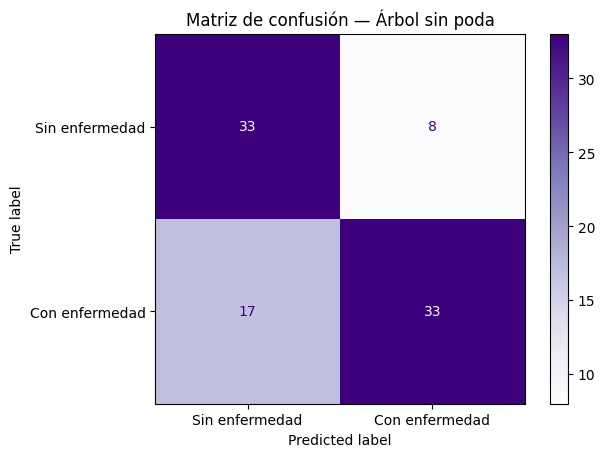

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Sin enfermedad","Con enfermedad"])
disp.plot(cmap="Purples")
plt.title("Matriz de confusión — Árbol sin poda")
plt.show()

In [ ]:
# Métricas resumidas
metrics = ["accuracy", "recall", "specificidad", "precision", "f1"]
values  = [accuracy_score(y_test, y_pred),
           recall_score(y_test, y_pred),
           specificity_score(y_test, y_pred),
           precision_score(y_test, y_pred),
           f1_score(y_test, y_pred)]
metricas_base = pd.DataFrame({"metric": metrics, "value": values})
metricas_base

,metric,value
0,accuracy,0.725275
1,recall,0.660000
2,specificidad,0.804878
3,precision,0.804878
4,f1,0.725275


## <FONT SIZE=4 COLOR="purple"> 2.2 Visualización del árbol </FONT>

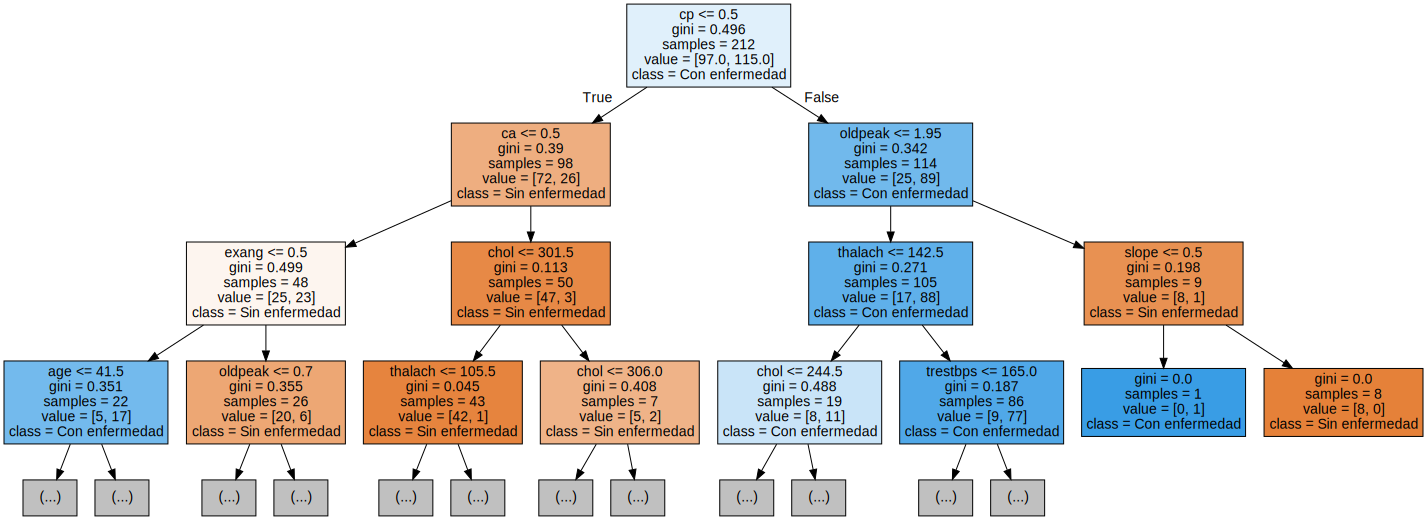

In [ ]:
from sklearn.tree import export_graphviz
from graphviz     import Source

dot_data = export_graphviz(
    modelo_tree,
    feature_names = X.columns,
    class_names   = ["Sin enfermedad", "Con enfermedad"],
    filled        = True,
    max_depth     = 3         # mostramos solo los primeros 3 niveles para legibilidad (variar)
)
Source(dot_data, format="png")

### <FONT SIZE=3 COLOR="purple"> ¿Cómo leer este árbol? </FONT>

Cada rectángulo (nodo) muestra:
- **La pregunta** que se hace (por ejemplo: `ca <= 0.5`)
- **gini**: el nivel de impureza de ese nodo (cercano a 0 = muy puro)
- **samples**: cuántos pacientes del entrenamiento llegaron a ese nodo
- **value**: cuántos son de cada clase `[sin enfermedad, con enfermedad]`
- **class**: la clase mayoritaria en ese nodo (la predicción si se detuviera aquí)

Los nodos en **tono más intenso** son los más puros.

## <FONT SIZE=4 COLOR="purple"> 2.3 Hiperparámetros y búsqueda en grilla </FONT>

Los principales hiperparámetros de un árbol de decisión son:

| Hiperparámetro | Descripción |
|---|---|
| `criterion` | Criterio de impureza: `gini` o `entropy` |
| `max_depth` | Profundidad máxima del árbol |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en un nodo hoja |
| `max_features` | Número máximo de variables candidatas por división |

> Los más influyentes suelen ser `criterion` y `max_depth`.

In [ ]:
# Búsqueda en grilla
modelo_gs = DecisionTreeClassifier(random_state=123)

grid_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None] + list(range(2, 12))
}

grid_tree = GridSearchCV(
    modelo_gs,
    grid_params,
    cv      = 10,
    scoring = "accuracy",
    verbose = 1
)

grid_tree.fit(X_train, y_train)

Fitting 10 folds for each of 22 candidates, totalling 220 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=123),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy', verbose=1)

In [ ]:
print("Mejor accuracy (CV):", round(grid_tree.best_score_, 4))
print("Mejores hiperparámetros:", grid_tree.best_params_)
modelo_tree_best = grid_tree.best_estimator_

Mejor accuracy (CV): 0.8115
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 5}


In [ ]:
# Evaluación del mejor modelo de grilla
y_pred_best = modelo_tree_best.predict(X_test)
print("========== Evaluación — Mejor árbol (GridSearch) ==========")
print(classification_report(y_test, y_pred_best))

========== Evaluación — Mejor árbol (GridSearch) ==========
              precision    recall  f1-score   support

           0       0.70      0.78      0.74        41
           1       0.80      0.72      0.76        50

    accuracy                           0.75        91
   macro avg       0.75      0.75      0.75        91
weighted avg       0.75      0.75      0.75        91



Matriz de confusión:
[[32  9]
 [14 36]]


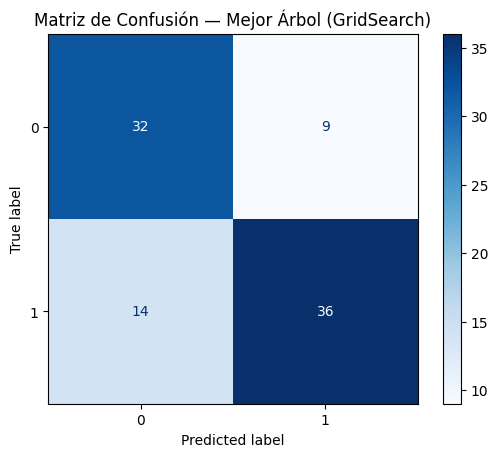

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
print("Matriz de confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión — Mejor Árbol (GridSearch)")
plt.show()

## <FONT SIZE=4 COLOR="purple"> 2.4 Ejercicios </FONT>



### <FONT SIZE=3 COLOR="purple"> 2.4.1. Ejercicio — Análisis conceptual </FONT>

Responde con tus propias palabras:

a) En un árbol de decisión, ¿qué significa que un nodo tenga un **Gini = 0**? ¿Es eso bueno o malo? ¿Por qué?

b) Qué sucede si el árbol tiene un accuracy del 100% en entrenamiento. ¿Es bueno o malo? Explica.

c)  Si el árbol sin poda tiene una profundidad de 8 y el árbol con GridSearch encontró que la profundidad óptima es 4, ¿qué le está pasando al árbol de profundidad 8 con los datos de entrenamiento? ¿Y con los de prueba?

*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="purple"> 2.4.2. Ejercicio — Interpretar la salida del GridSearch </FONT>

Después de ejecutar el GridSearch, observa la siguiente salida hipotética:

```
Mejor accuracy (CV): 0.8123
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 4}
```

Y el reporte de clasificación del modelo óptimo da:
```
              precision    recall  f1-score   support

           0       0.78      0.83      0.80        41
           1       0.84      0.79      0.81        50

    accuracy                           0.81        91
```

a) El GridSearch usó `cv=10`. ¿Qué significa eso en términos de cómo se evaluó el modelo?  
b) La profundidad óptima fue 4. Si la profundidad sin restricciones era 8, ¿cuántos niveles se "recortaron"?  
c) ¿Cuál clase tiene mejor precision y cuál tiene mejor recall? ¿Qué implicación clínica tiene eso?



*Escribe tu respuesta aquí:*


### <FONT SIZE=3 COLOR="purple"> 2.4.3. Ejercicio — Exploración práctica de hiperparámetros </FONT>


Modifica el siguiente código para experimentar con el árbol:

```python
# MODIFICA estos valores y observa cómo cambian las métricas
mi_arbol = DecisionTreeClassifier(
    criterion        = "gini",     # Prueba también: "entropy"
    max_depth        = 4,          # Prueba: 2, 6, 10, None
    min_samples_leaf = 1,          # Prueba: 5, 10, 20
    random_state     = 123
)
mi_arbol.fit(X_train, y_train)
y_pred_mio = mi_arbol.predict(X_test)

print(f"Profundidad: {mi_arbol.get_depth()} | Hojas: {mi_arbol.get_n_leaves()}")
print(f"Accuracy en entrenamiento: {accuracy_score(y_train, mi_arbol.predict(X_train)):.4f}")
print(f"Accuracy en prueba:        {accuracy_score(y_test, y_pred_mio):.4f}")
```

In [ ]:
# Tu código aquí

Llena la siguiente tabla con tus resultados:

| `max_depth` | `min_samples_leaf` | Acc. entrenamiento | Acc. prueba | ¿Sobreajuste? |
|---|---|---|---|---|
| None | 1 | | | |
| 4 | 1 | | | |
| 2 | 1 | | | |
| 4 | 10 | | | |
| 4 | 20 | | | |

¿Qué conclusión sacas sobre la relación entre profundidad, tamaño de hojas y sobreajuste?

# <FONT SIZE=5 COLOR="purple"> 3. Poda (Pruning) </FONT>

Los árboles de decisión, cuando se les permite crecer libremente, tienden a aprender ruido y patrones muy específicos a partir de los datos de entrenamiento, lo que lleva a un ajuste excesivo. La **poda** aborda este problema simplificando la estructura del árbol, mejorando la generalización de los datos invisibles, mejorando la interpretabilidad y reduciendo el costo computacional, al tiempo que mantiene o incluso mejora la precisión general del modelo.

- Reduce el sobreajuste eliminando las divisiones impulsadas por el ruido
- Mejora la generalización de los datos invisibles
- Simplifica la estructura del árbol de decisión
- Mejora la interpretabilidad de las normas de decisión
- Mejora la formación y la eficiencia de la inferencia

La poda de árbol de decisión es una técnica de optimización de modelos utilizada para controlar el crecimiento de modelos de árboles de decisión mediante la eliminación de ramas y nodos innecesarios que no contribuyen significativamente al rendimiento predictivo.

<center>
  <img src="https://miro.medium.com/v2/1*7BjLEC5vSpBXnD3sPhzEsQ.png" width="700"/>
  <br>
  <small>
    Fuente: https://medium.com/@sushmita2310/a-comprehensive-guide-to-pre-pruning-and-post-pruning-in-decision-trees-c556c48aafdf
  </small>
</center>

<br>
Existen dos grandes estrategias de poda:

1. **Pre-poda (Pre-pruning)**: se detiene el crecimiento del árbol de forma anticipada, imponiendo restricciones durante el entrenamiento (por ejemplo, `max_depth`, `min_samples_leaf`).

2. **Post-poda (Post-pruning)**: primero se deja crecer el árbol completamente y luego se eliminan ramas según algún criterio. El método más común en scikit-learn es el **CCP** (Cost Complexity Pruning).

<br>

| Estrategia | Ventaja | Desventaja |
|---|---|---|
| Pre-poda | Más rápida, fácil de interpretar | Puede detener el árbol antes de tiempo |
| Post-poda | Más precisa, explora más soluciones | Más costosa computacionalmente |

## <FONT SIZE=4 COLOR="blue"> 3.1 Pre-poda (Pre-pruning) </FONT>

En la pre-poda restringimos el crecimiento del árbol desde el inicio usando los hiperparámetros que ya conocemos.  
Veamos el efecto de variar la profundidad máxima (`max_depth`) sobre el rendimiento en entrenamiento y prueba.

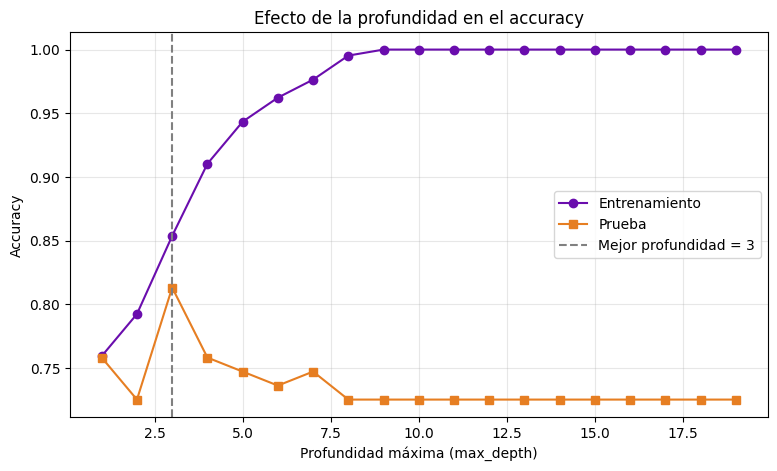

Mejor profundidad sobre prueba: 3  |  Accuracy: 0.8132


In [ ]:
# Efecto de max_depth sobre accuracy de entrenamiento y prueba
train_scores = []
test_scores  = []
depths       = list(range(1, 20))

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=123)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker="o", label="Entrenamiento", color="#6A0DAD")
plt.plot(depths, test_scores,  marker="s", label="Prueba",        color="#E67E22")
plt.axvline(depths[test_scores.index(max(test_scores))],
            linestyle="--", color="gray", label=f"Mejor profundidad = {depths[test_scores.index(max(test_scores))]}")
plt.xlabel("Profundidad máxima (max_depth)")
plt.ylabel("Accuracy")
plt.title("Efecto de la profundidad en el accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f"Mejor profundidad sobre prueba: {best_depth}  |  Accuracy: {max(test_scores):.4f}")

In [ ]:
# Modelo con pre-poda (mejor max_depth encontrado)
modelo_prepoda = DecisionTreeClassifier(max_depth=best_depth, random_state=123)
modelo_prepoda.fit(X_train, y_train)
y_pred_prepoda = modelo_prepoda.predict(X_test)

print(f"Profundidad: {modelo_prepoda.get_depth()}  |  Hojas: {modelo_prepoda.get_n_leaves()}")
print()
print("========== Evaluación — Árbol con pre-poda ==========")
print(classification_report(y_test, y_pred_prepoda))

Profundidad: 3  |  Hojas: 8

========== Evaluación — Árbol con pre-poda ==========
              precision    recall  f1-score   support

           0       0.82      0.76      0.78        41
           1       0.81      0.86      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



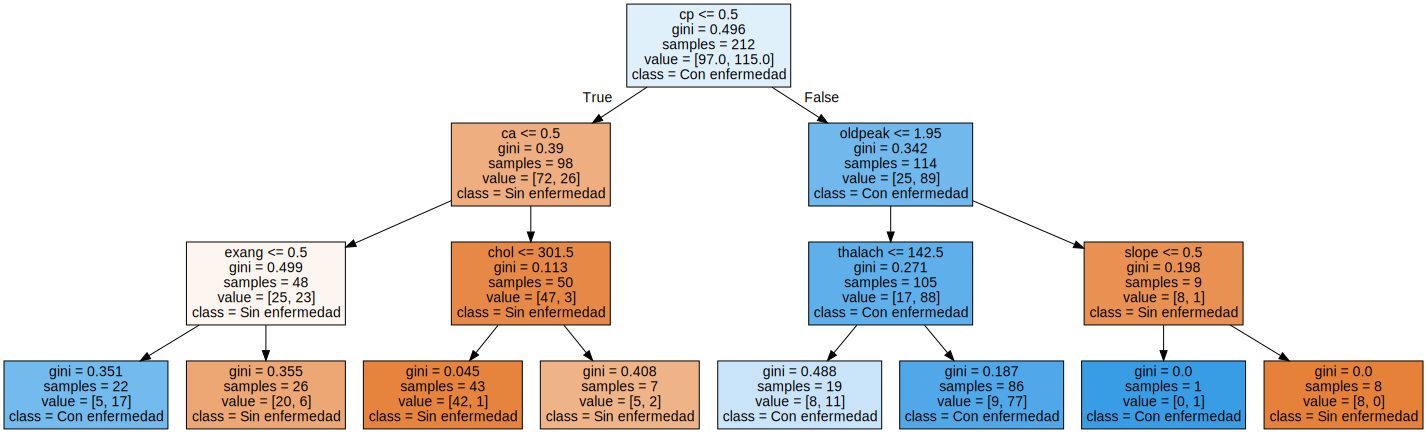

In [ ]:
# Visualización del árbol podado
dot_prepoda = export_graphviz(
    modelo_prepoda,
    feature_names = X.columns,
    class_names   = ["Sin enfermedad", "Con enfermedad"],
    filled        = True
)
Source(dot_prepoda, format="png")

## <FONT SIZE=4 COLOR="blue"> 3.2. Ejercicios — Poda  (Pre-pruning) </FONT>


### <FONT SIZE=3 COLOR="blue"> 3.2.1. Ejercicio — Análisis conceptual </FONT>

a) Observa la gráfica de "profundidad vs accuracy". A partir de cierta profundidad, el accuracy de entrenamiento sigue subiendo pero el de prueba se estanca o baja. ¿Cómo se llama ese fenómeno? ¿Por qué ocurre?

b) ¿Por qué no conviene siempre elegir el árbol más profundo, si ese maximiza el accuracy en entrenamiento?

c) Explica con una analogía cotidiana (no técnica) la diferencia entre un árbol que "memoriza" y uno que "aprende".


*Escribe tu respuesta aquí:*


### <FONT SIZE=3 COLOR="blue"> 3.2.2. Ejercicio — Interpretar la gráfica de profundidad </FONT>

Observa la siguiente gráfica hipotética de profundidad vs accuracy:

```
Profundidad  | Acc. Entrenamiento | Acc. Prueba
─────────────┼────────────────────┼─────────────
     1        |       0.72         |    0.70
     2        |       0.78         |    0.76
     3        |       0.83         |    0.81
     4        |       0.87         |    0.83  ← máximo en prueba
     5        |       0.91         |    0.82
     8        |       0.98         |    0.78
    12        |       1.00         |    0.74
```

a) ¿Cuál sería la profundidad óptima según esta tabla? ¿Por qué?  
b) ¿En qué profundidad empieza claramente el sobreajuste?  
c) Un árbol con profundidad 1 tiene accuracy de 0.72 en prueba y el óptimo tiene 0.83. ¿Vale la pena la complejidad extra del árbol más profundo?

*Escribe tu respuesta aquí:*



### <FONT SIZE=3 COLOR="blue"> 3.2.3. Ejercicio — Exploración: efectos combinados de pre-poda </FONT>

Experimenta combinando dos hiperparámetros de pre-poda simultáneamente. Rellena la tabla:

```python
# Modifica los valores y observa
for depth in [2, 4, 6]:
    for min_leaf in [1, 5, 10]:
        clf = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_leaf, random_state=123)
        clf.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, clf.predict(X_train))
        acc_test  = accuracy_score(y_test, clf.predict(X_test))
        print(f"depth={depth}, min_leaf={min_leaf} | Train: {acc_train:.3f} | Test: {acc_test:.3f}")
```

¿Cuál combinación da el mejor balance entre entrenamiento y prueba?


# <FONT SIZE=5 COLOR="green"> 4. CCP — Cost Complexity Pruning (Post-poda) </FONT>

El **Cost Complexity Pruning (CCP)**, también conocido como *Weakest Link Pruning*, es la técnica de **post-poda** utilizada en árboles de decisión en `scikit-learn` por defecto.
<br>

<FONT SIZE=4 COLOR="green"> **Idea intuitiva** </FONT>

Cuando entrenamos un árbol de decisión sin restricciones, este tiende a crecer mucho y a ajustarse demasiado a los datos de entrenamiento (*overfitting*). Esto genera ramas que capturan ruido en lugar de patrones reales.
<br>
<br>

El CCP propone una idea sencilla:  
**no todas las ramas del árbol valen la pena.**
<br>
<br>

Cada rama adicional hace el modelo más complejo. Entonces, el algoritmo evalúa si esa complejidad extra realmente mejora el rendimiento. Si una rama no aporta suficiente mejora, se elimina.
<br>

Es como tener un "presupuesto de complejidad":
- Cada nueva rama tiene un costo.
- Si el beneficio no justifica ese costo, la rama se poda.
<br>
<br>

El parámetro clave es **α (alpha)**, que controla qué tan estricto eres con ese presupuesto:

- **α = 0**: no hay penalización, el árbol crece al máximo.
- **α pequeño**: se eliminan solo las ramas menos útiles.
- **α grande**: se poda de forma agresiva → árbol más simple.
<br>
<br>

El objetivo es encontrar un valor de α que logre un equilibrio entre:
- buen rendimiento
- baja complejidad
<br>
<br>

<FONT SIZE=4 COLOR="green"> **Intuición del algoritmo** </FONT>

El proceso es:
1. Se entrena un árbol completo (sin restricciones).
2. Se evalúan todas las posibles podas.
3. Se eliminan primero las ramas "más débiles" (las que menos aportan).
4. Se genera una secuencia de árboles cada vez más simples.
5. Se elige el mejor según validación.

<br>
<br>
<br>


<FONT SIZE=4 COLOR="green"> **Fórmulas matemáticas (para el detalle matemático)** </FONT>

El CCP define una función de costo que penaliza la complejidad del árbol:

$$
R_\alpha(T) = R(T) + \alpha \cdot |T|
$$

donde:
- $R(T)$ es el error total del árbol $T$ sobre los datos de entrenamiento.
- $|T|$ es el número de nodos hoja.
- $\alpha \geq 0$ es el parámetro de complejidad.

La idea es minimizar esta función: balancear error y tamaño del árbol.

Para decidir qué rama podar, el algoritmo calcula el **alpha efectivo**:

$$
\tilde{\alpha} = \frac{R(t) - R(T_t)}{|T_t| - 1}
$$

donde:
- $R(t)$ es la impureza del nodo.
- $R(T_t)$ es la impureza del subárbol con raíz en ese nodo.
- $|T_t|$ es el número de hojas de ese subárbol.

La rama con menor $\tilde{\alpha}$ es la primera en eliminarse, ya que es la que menos aporta en relación a su complejidad.



## <FONT SIZE=4 COLOR="green"> 4.1 Cálculo de los alphas efectivos </FONT>

In [ ]:
# Obtener la ruta de poda completa
# cost_complexity_pruning_path devuelve los alphas y las impurezas correspondientes
path    = DecisionTreeClassifier(random_state=123).cost_complexity_pruning_path(X_train, y_train)
alphas  = path.ccp_alphas      # secuencia de alphas efectivos
impurezas = path.impurities    # impureza acumulada de las hojas para cada alpha

print(f"Número de alphas: {len(alphas)}")
print(f"Alpha mínimo: {alphas.min():.6f}")
print(f"Alpha máximo: {alphas.max():.6f}")

Número de alphas: 21
Alpha mínimo: 0.000000
Alpha máximo: 0.132060


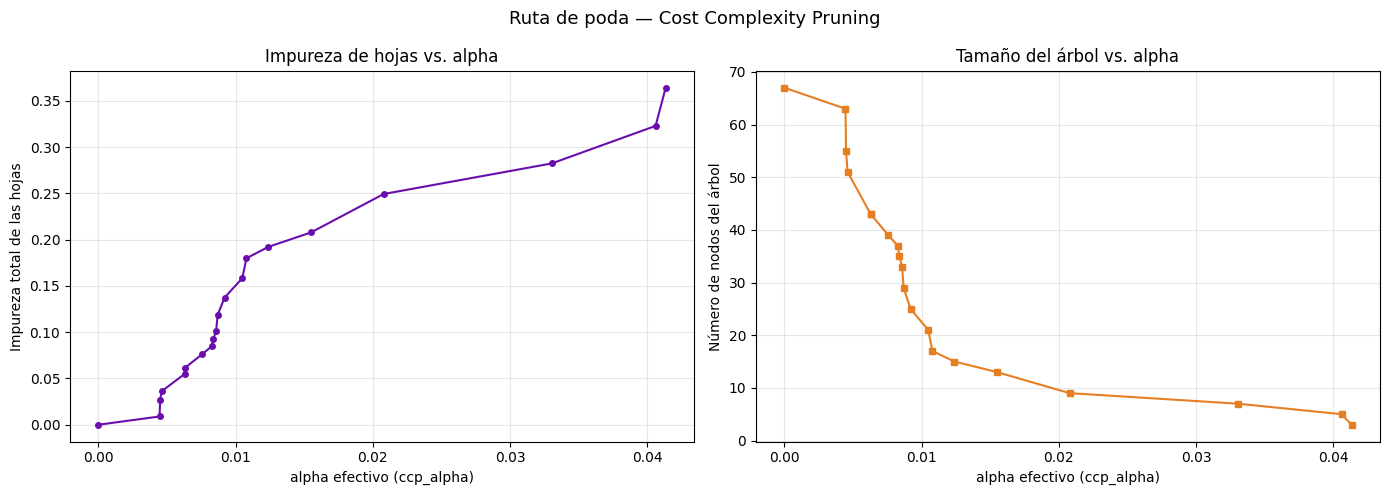

In [ ]:
# Visualización: impureza de las hojas vs alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: impureza vs alpha
axes[0].plot(alphas[:-1], impurezas[:-1], marker="o", color="#6A0DAD", markersize=4)
axes[0].set_xlabel("alpha efectivo (ccp_alpha)")
axes[0].set_ylabel("Impureza total de las hojas")
axes[0].set_title("Impureza de hojas vs. alpha")
axes[0].grid(True, alpha=0.3)

# Gráfico 2: número de nodos vs alpha
n_nodos = []
for a in alphas[:-1]:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    clf.fit(X_train, y_train)
    n_nodos.append(clf.tree_.node_count)

axes[1].plot(alphas[:-1], n_nodos, marker="s", color="#E67E22", markersize=4)
axes[1].set_xlabel("alpha efectivo (ccp_alpha)")
axes[1].set_ylabel("Número de nodos del árbol")
axes[1].set_title("Tamaño del árbol vs. alpha")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Ruta de poda — Cost Complexity Pruning", fontsize=13)
plt.tight_layout()
plt.show()

## <FONT SIZE=4 COLOR="green"> 4.2 Selección del alpha óptimo con validación cruzada </FONT>

Para encontrar el **mejor alpha** usamos validación cruzada (cross-validation).  
Entrenamos un árbol para cada valor de alpha y evaluamos el accuracy promedio en CV.  
El alpha óptimo es el que maximiza el accuracy de generalización.

In [ ]:
# Accuracy de entrenamiento y prueba para cada alpha
train_acc_ccp = []
test_acc_ccp  = []

# Evitar alphas muy grandes (árbol trivial) tomando todos menos el último
alphas_cv = alphas[:-1]

for a in alphas_cv:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    clf.fit(X_train, y_train)
    train_acc_ccp.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc_ccp.append(accuracy_score(y_test,  clf.predict(X_test)))

# Encontrar el mejor alpha
best_alpha_idx = test_acc_ccp.index(max(test_acc_ccp))
best_alpha     = alphas_cv[best_alpha_idx]

print(f"Alpha óptimo:     {best_alpha:.6f}")
print(f"Accuracy (prueba): {max(test_acc_ccp):.4f}")

Alpha óptimo:     0.020780
Accuracy (prueba): 0.7802


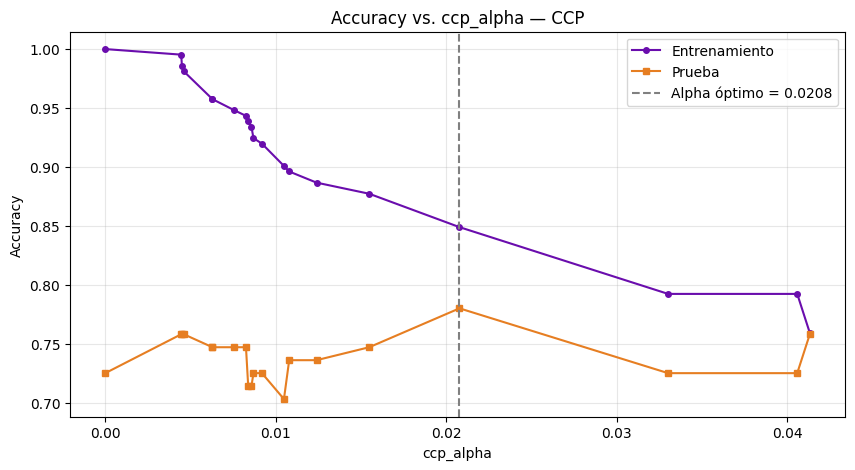

In [ ]:
# Visualización
plt.figure(figsize=(10, 5))
plt.plot(alphas_cv, train_acc_ccp, marker="o", label="Entrenamiento", color="#6A0DAD", markersize=4)
plt.plot(alphas_cv, test_acc_ccp,  marker="s", label="Prueba",        color="#E67E22", markersize=4)
plt.axvline(best_alpha, linestyle="--", color="gray", label=f"Alpha óptimo = {best_alpha:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. ccp_alpha — CCP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## <FONT SIZE=4 COLOR="green"> 4.3 Modelo final con CCP </FONT>

In [ ]:
# Entrenamiento del modelo con el alpha óptimo
modelo_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=123)
modelo_ccp.fit(X_train, y_train)
y_pred_ccp = modelo_ccp.predict(X_test)

print(f"Profundidad del árbol podado: {modelo_ccp.get_depth()}")
print(f"Número de hojas:              {modelo_ccp.get_n_leaves()}")
print()
print("========== Evaluación — Árbol con CCP ==========")
print(classification_report(y_test, y_pred_ccp))

Profundidad del árbol podado: 3
Número de hojas:              5

========== Evaluación — Árbol con CCP ==========
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        41
           1       0.80      0.80      0.80        50

    accuracy                           0.78        91
   macro avg       0.78      0.78      0.78        91
weighted avg       0.78      0.78      0.78        91



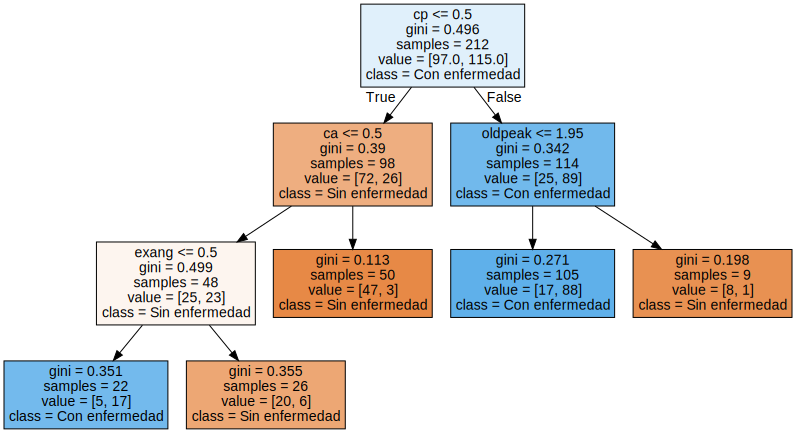

In [ ]:
# Visualización del árbol podado con CCP
dot_ccp = export_graphviz(
    modelo_ccp,
    feature_names = X.columns,
    class_names   = ["Sin enfermedad", "Con enfermedad"],
    filled        = True
)
Source(dot_ccp, format="png")

## <FONT SIZE=5 COLOR="green"> 4.4. Ejercicios — CCP </FONT>



### <FONT SIZE=4 COLOR="green"> 4.4.1. Ejercicio — Análisis conceptual </FONT>

a) En tus propias palabras, explica qué hace el parámetro alpha en el CCP. Usa una analogía que no sea técnica (por ejemplo: un árbol genealógico, un organigrama, un mapa mental, etc.)

b) Si el alpha óptimo encontrado es muy pequeño (cercano a 0), ¿qué nos dice eso sobre el árbol original? ¿Tenía mucho sobreajuste o poco?

c) ¿Por qué es importante usar el conjunto de **prueba** (y no el de entrenamiento) para seleccionar el alpha óptimo?


*Escribe tu respuesta aquí:*

### <FONT SIZE=4 COLOR="green"> 4.4.2. Ejercicio — Interpretar la gráfica de alpha vs accuracy</FONT>

Observa la siguiente gráfica hipotética de CCP:

```
alpha       | Acc. Entrenamiento | Acc. Prueba
────────────┼────────────────────┼─────────────
0.000       |       1.00         |    0.74   ← árbol sin poda
0.002       |       0.95         |    0.79
0.005       |       0.89         |    0.83
0.008       |       0.86         |    0.84  ← alpha óptimo
0.012       |       0.82         |    0.82
0.020       |       0.78         |    0.78
0.050       |       0.72         |    0.71   ← árbol muy podado
```

a) Con alpha = 0.000, ¿hay sobreajuste? ¿Cómo lo identificas?  
b) ¿Cuál sería el alpha óptimo y por qué?  
c) ¿Qué pasa cuando el alpha es 0.050? ¿El modelo está sobreajustado o subajustado? ¿Por qué?  
d) ¿Por qué con alpha = 0.012 el accuracy de entrenamiento y de prueba son iguales (0.82)?

*Escribe tu respuesta aquí:*



### <FONT SIZE=4 COLOR="green"> 4.4.3. Ejercicio — Comparar manualmente distintos alphas</FONT>

Elige 5 valores de alpha de la ruta de poda calculada y compara sus árboles resultantes:

```python
# Elige 5 alphas distintos de la variable alphas_cv (que ya calculamos)
# Por ejemplo: alphas_cv[0], alphas_cv[5], alphas_cv[10], alphas_cv[15], alphas_cv[-1]
alphas_elegidos = [alphas_cv[0], alphas_cv[5], alphas_cv[10], alphas_cv[15], alphas_cv[-1]]

for a in alphas_elegidos:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=123)
    clf.fit(X_train, y_train)
    print(f"alpha={a:.5f} | profundidad={clf.get_depth()} | hojas={clf.get_n_leaves()} "
          f"| Acc prueba={accuracy_score(y_test, clf.predict(X_test)):.3f}")
```

¿Cuál es la relación entre alpha, profundidad y accuracy? ¿Siempre más simple es mejor?

---

# <FONT SIZE=5 COLOR="green"> 5. Importancia de las características </FONT>


Una de las ventajas más grandes de los árboles de decisión es que nos dicen qué variables fueron más útiles para hacer las predicciones. A esto se le llama **feature importance** (importancia de las características).

La importancia de cada variable se calcula como la suma de las reducciones de impureza (Gini) que esa variable logró en todos los nodos donde fue usada, ponderada por el número de observaciones. Cuanto mayor sea este número, más veces el árbol decidió usar esa variable para separar los grupos.

In [ ]:
# Importancia de variables del árbol con CCP
importancia = pd.DataFrame({
    "predictor":   X_train.columns.tolist(),
    "importancia": modelo_ccp.feature_importances_
}).sort_values("importancia", ascending=False)

print("Importancia de las variables — Árbol con CCP")
print("----------------------------------------------")
importancia

Importancia de las variables — Árbol con CCP
----------------------------------------------


,predictor,importancia
2,cp,0.534647
9,oldpeak,0.167328
11,ca,0.164342
8,exang,0.133683
0,age,0.000000
4,chol,0.000000
3,trestbps,0.000000
1,sex,0.000000
5,fbs,0.000000
7,thalach,0.000000


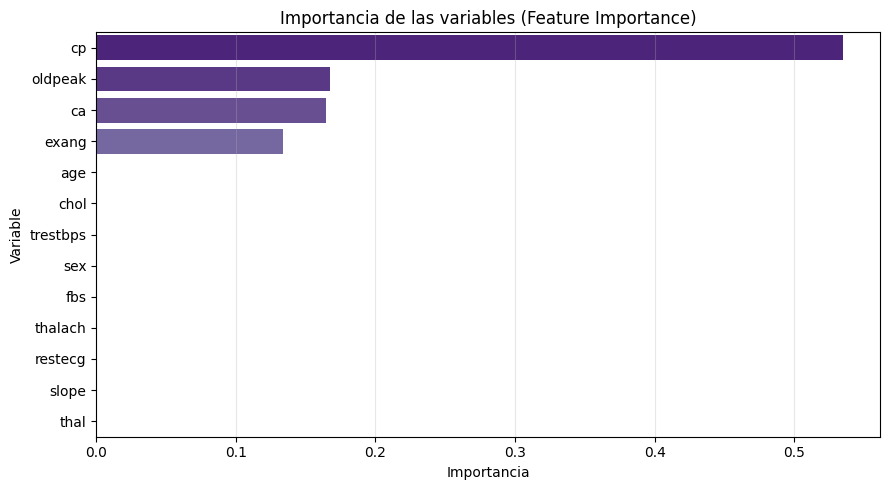

In [ ]:
# Gráfico de importancia
plt.figure(figsize=(9, 5))
sns.barplot(data=importancia, x="importancia", y="predictor",
            palette="Purples_r")
plt.title("Importancia de las variables (Feature Importance)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# <FONT SIZE=5 COLOR="green"> 6. Comparación de modelos </FONT>

Ahora comparemos los tres árboles que entrenamos: sin poda, con pre-poda y con CCP (post-poda). La pregunta clave es: **¿Vale la pena la complejidad extra de la poda?**

In [ ]:
# Tabla comparativa de los tres árboles
modelos = {
    "Árbol sin poda":  (modelo_tree,    X_test,  y_test),
    "Pre-poda":        (modelo_prepoda, X_test,  y_test),
    "CCP (post-poda)": (modelo_ccp,     X_test,  y_test),
}

rows = []
for nombre, (m, Xt, yt) in modelos.items():
    yp = m.predict(Xt)
    rows.append({
        "Modelo":        nombre,
        "Profundidad":   m.get_depth(),
        "Hojas":         m.get_n_leaves(),
        "Accuracy":      round(accuracy_score(yt, yp), 4),
        "Recall":        round(recall_score(yt, yp), 4),
        "Specificidad":  round(specificity_score(yt, yp), 4),
        "Precision":     round(precision_score(yt, yp), 4),
        "F1":            round(f1_score(yt, yp), 4),
    })

comparacion = pd.DataFrame(rows).set_index("Modelo")
comparacion

,Profundidad,Hojas,Accuracy,Recall,Specificidad,Precision,F1
Modelo,,,,,,,
Árbol sin poda,9,34,0.7253,0.66,0.8049,0.8049,0.7253
Pre-poda,3,8,0.8132,0.86,0.7561,0.8113,0.8350
CCP (post-poda),3,5,0.7802,0.80,0.7561,0.8000,0.8000


# <FONT SIZE=5 COLOR="green"> 7. Curva ROC </FONT>

Ya vimos la curva ROC en la sesión anterior. Aquí la usamos para comparar los tres árboles que entrenamos: sin poda, con pre-poda y con CCP.

Recuerda: queremos que la curva esté lo más cerca posible de la esquina superior izquierda. El AUC resume esto en un número entre 0 y 1.

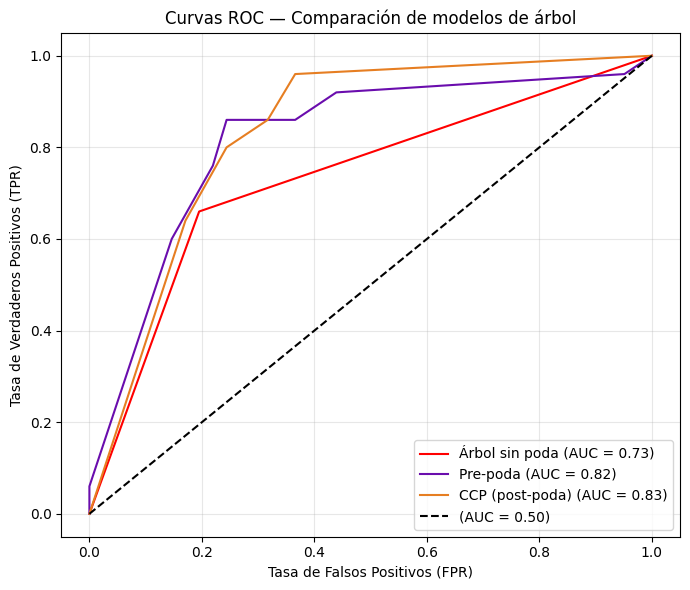

In [ ]:
# Curvas ROC de los tres modelos
fig, ax = plt.subplots(figsize=(7, 6))

colores = {"Árbol sin poda": "red", "Pre-poda": "#6A0DAD", "CCP (post-poda)": "#E67E22"}

for nombre, (m, Xt, yt) in modelos.items():
    proba = m.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(yt, proba)
    auc = roc_auc_score(yt, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.2f})", color=colores[nombre])

ax.plot([0, 1], [0, 1], "k--", label="(AUC = 0.50)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curvas ROC — Comparación de modelos de árbol")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# <FONT SIZE=5 COLOR="green"> 8. Resumen </FONT>

Hemos trabajado tres variantes del mismo modelo de **árbol de decisión** sobre la base de datos de enfermedades cardíacas:

1. **Árbol sin poda**: el modelo crece al máximo, clasificando perfectamente el entrenamiento pero con overfitting en prueba.

2. **Pre-poda (max_depth)**: al limitar la profundidad, logramos un árbol más sencillo y con mejor generalización. Es la estrategia más rápida y directa.

3. **Post-poda con CCP**: el método más sofisticado. Dejamos que el árbol crezca y luego encontramos el parámetro $\alpha$ óptimo usando la ruta de poda. Es el enfoque recomendado por scikit-learn.

**Regla general:** siempre que un árbol sin restricciones muestre un accuracy de entrenamiento mucho mayor que el de prueba, es señal de sobreajuste → aplicar poda.